<a href="https://colab.research.google.com/github/raufur-simanto/Boreal-Forest-Fire-Detection-with-Vision-Mamba/blob/main/notebooks/03_rtdetr_baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03 — Transformer Baseline (RT-DETR)
## Boreal Forest Fire Detection Using Vision Mamba

### Why RT-DETR instead of TFNet?

TFNet (Liu et al., 2025) is cited in the literature review as the primary transformer-based
forest fire detection method. However, **no official code repository exists** for TFNet,
making a faithful reimplementation risky (implementation errors could produce unfair comparisons).

**RT-DETR** (Real-Time DEtection TRansformer, Zhao et al., 2024) is used as the
implemented transformer baseline because:
- Available directly in `ultralytics` — same training pipeline as the YOLO baselines
- Uses a hybrid CNN-Transformer encoder (HGNetv2 + transformer queries)
- Designed for real-time detection — relevant to our RQ2 (efficiency)
- Represents the state of the art in transformer-based object detection

TFNet is still discussed in the thesis as contextual prior work; RT-DETR is the
**experimentally implemented transformer baseline**.

**Prerequisites:** Run `01_dataset_prep.ipynb` first.

## 1 — Install Packages

In [1]:
!pip install ultralytics torchinfo -q
print('Done.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 24.1 MB/s eta 0:00:00
Done.


In [2]:
import os
from pathlib import Path
import yaml
import shutil
from datetime import datetime

import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from ultralytics import YOLO

# Set random seed
torch.manual_seed(42)
np.random.seed(42)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## 2 — Mount Drive & Configure Paths

In [3]:
from google.colab import drive
drive.mount('/content/drive')

import os, torch

BASE_DIR    = Path('/content/drive/MyDrive/thesis')
data_root = os.path.join(BASE_DIR, 'data', 'boreal')
BOREAL_YAML = os.path.join(BASE_DIR, 'data', 'boreal', 'data.yaml')
CKPT_DIR    = os.path.join(BASE_DIR, 'checkpoints')
RESULTS_DIR = os.path.join(BASE_DIR, 'results')

for d in [CKPT_DIR, RESULTS_DIR]:
    os.makedirs(d, exist_ok=True)

assert os.path.exists(BOREAL_YAML), 'data.yaml not found — run notebook 01 first!'
print('YAML :', BOREAL_YAML)
print('CUDA :', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU  :', torch.cuda.get_device_name(0))


print(f" Dataset found at: {BOREAL_YAML}")
print(f" Checkpoints will be saved to: {CKPT_DIR}")
print(f" Results will be saved to: {RESULTS_DIR}")

Mounted at /content/drive
YAML : /content/drive/MyDrive/thesis/data/boreal/data.yaml
CUDA : True
GPU  : NVIDIA A100-SXM4-40GB
 Dataset found at: /content/drive/MyDrive/thesis/data/boreal/data.yaml
 Checkpoints will be saved to: /content/drive/MyDrive/thesis/checkpoints
 Results will be saved to: /content/drive/MyDrive/thesis/results


In [4]:
# Load and display data.yaml
with open(BOREAL_YAML, 'r') as f:
    data_config = yaml.safe_load(f)

print("Dataset Configuration:")
print("=" * 50)
for key, value in data_config.items():
    print(f"{key:10s}: {value}")
print("=" * 50)

Dataset Configuration:
names     : ['smoke']
nc        : 1
path      : /content/drive/MyDrive/thesis/data/boreal
test      : images/test
train     : images/train
val       : images/val


In [5]:
# Count images in each split
DATA_ROOT = Path('/content/drive/MyDrive/thesis/data/boreal')
splits = ['train', 'val', 'test']
for split in splits:
    img_dir = DATA_ROOT / 'images' / split
    n_images = len(list(img_dir.glob('*')))
    print(f"{split.capitalize():5s}: {n_images:4d} images")

print("\nDataset verified and ready for training!")

Train: 2551 images
Val  :  638 images
Test : 1765 images

Dataset verified and ready for training!


In [6]:
# Training configuration
EPOCHS = 100
BATCH_SIZE = 32  # Adjust based on GPU memory (use 8 for T4, 32 for A100)
IMG_SIZE = 640
DEVICE = 0 if torch.cuda.is_available() else 'cpu'

print("Training Configuration:")
print(f"  Epochs: {EPOCHS}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Image size: {IMG_SIZE}")
print(f"  Device: {DEVICE}")

Training Configuration:
  Epochs: 100
  Batch size: 32
  Image size: 640
  Device: 0


---
# RT-DETR — Transformer Baseline

## 3 — Model Overview

RT-DETR architecture (Zhao et al., 2024):
- **Backbone:** HGNetv2 (efficient CNN feature extractor)
- **Encoder:** Hybrid CNN + AIFI transformer attention module
- **Decoder:** Transformer decoder with object queries
- **Output:** Direct set prediction (no NMS needed)

We use **RT-DETR-l** (large variant, ~32M params) — closest in size to Vision Mamba (vim-small ~26M).

In [7]:
from ultralytics import YOLO
from torchinfo import summary

# Inspect RT-DETR-l parameter count before training
model_rtdetr = YOLO('rtdetr-l.pt')  # COCO pretrained
pt = model_rtdetr.model
n_params = sum(p.numel() for p in pt.parameters()) / 1e6
print(f'RT-DETR-l parameters: {n_params:.1f} M')

RT-DETR-l parameters: 33.0 M


## 4 — Train RT-DETR on Boreal Dataset (val split used each epoch)

In [8]:
# RT-DETR requires a slightly lower LR than YOLO
model_rtdetr.train(
    data      = BOREAL_YAML,
    epochs    = 100,
    imgsz     = 640,
    batch     = 32,          # RT-DETR is heavier — reduce batch if OOM on A100
    lr0       = 1e-3,       # lower LR than YOLO — transformer decoders are sensitive
    optimizer = 'AdamW',
    name      = 'rtdetr_boreal',
    project   = CKPT_DIR,
    exist_ok  = True,
    patience  = 20,
    device    = 0 if torch.cuda.is_available() else 'cpu',
    save=True,
    save_period=10,  # Save checkpoint every 10 epochs
    plots=True,
    verbose=True
)
print("\n" + "="*60)
print(" Training complete!")

BEST_RTDETR = os.path.join(CKPT_DIR, 'rtdetr_boreal', 'weights', 'best.pt')
print('Best checkpoint:', BEST_RTDETR)

Ultralytics 8.4.24 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/thesis/data/boreal/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=rtdetr-l.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=rtdetr_boreal, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, o

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      1/100      23.8G     0.5606      2.316     0.5918         51        640: 100% ━━━━━━━━━━━━ 80/80 2.9s/it 3:50
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 1.1s/it 10.9s
                   all        638        590    0.00393      0.461     0.0121    0.00593

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
      2/100      24.6G     0.3444      1.655     0.3374         56        640: 0% ──────────── 0/80  0.6s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      2/100      24.6G     0.3195      1.417     0.2886         40        640: 100% ━━━━━━━━━━━━ 80/80 1.7it/s 47.4s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 2.8it/s 3.6s
                   all        638        590     0.0991      0.588      0.139     0.0851

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
      3/100      24.2G      0.319      1.234     0.2854         69        640: 0% ──────────── 0/80  0.7s

...

     98/100        24G     0.1843      0.275     0.2593         21        640: 100% ━━━━━━━━━━━━ 80/80 1.6it/s 49.6s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 2.9it/s 3.5s
                   all        638        590      0.987      0.992      0.993      0.726

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
     99/100      24.5G     0.1763     0.2563      0.219         28        640: 0% ──────────── 0/80  0.6s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


     99/100      24.5G     0.1844     0.2759     0.2647         22        640: 100% ━━━━━━━━━━━━ 80/80 1.6it/s 49.8s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 2.7it/s 3.7s
                   all        638        590      0.981      0.992      0.987      0.719

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
    100/100      24.4G     0.3381      0.342     0.2096         35        640: 0% ──────────── 0/80  0.6s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


    100/100      24.4G      0.182     0.2754     0.2597         23        640: 100% ━━━━━━━━━━━━ 80/80 1.6it/s 48.9s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 2.9it/s 3.4s
                   all        638        590      0.988       0.99      0.993      0.722

100 epochs completed in 1.607 hours.
Optimizer stripped from /content/drive/MyDrive/thesis/checkpoints/rtdetr_boreal/weights/last.pt, 66.2MB
Optimizer stripped from /content/drive/MyDrive/thesis/checkpoints/rtdetr_boreal/weights/best.pt, 66.2MB

Validating /content/drive/MyDrive/thesis/checkpoints/rtdetr_boreal/weights/best.pt...
Ultralytics 8.4.24 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
rt-detr-l summary: 310 layers, 31,985,795 parameters, 0 gradients, 103.4 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 2.7it/s 3.8s
                   all        6

> **OOM tip (T4):** If you get CUDA out-of-memory, reduce `batch` to 4.  
> For A100 (Colab Pro), batch=32 is fine.

## 5 — Explicit Validation Evaluation

In [9]:
model_rtdetr_best = YOLO(BEST_RTDETR)

val_rtdetr = model_rtdetr_best.val(
    data   = BOREAL_YAML,
    split  = 'val',
    imgsz  = 640,
    batch  = 32,
    device = 0 if torch.cuda.is_available() else 'cpu'
)

print('\n=== RT-DETR — Validation Results ===')
print(f'  Precision : {val_rtdetr.box.mp:.4f}')
print(f'  Recall    : {val_rtdetr.box.mr:.4f}')
print(f'  mAP50     : {val_rtdetr.box.map50:.4f}')
print(f'  mAP50-95  : {val_rtdetr.box.map:.4f}')

Ultralytics 8.4.24 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
rt-detr-l summary: 310 layers, 31,985,795 parameters, 0 gradients, 103.4 GFLOPs
val: Fast image access ✅ (ping: 0.4±0.1 ms, read: 575.1±82.7 MB/s, size: 2461.3 KB)
val: Scanning /content/drive/MyDrive/thesis/data/boreal/labels/val.cache... 638 images, 48 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 638/638 178.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 20/20 1.9it/s 10.8s
                   all        638        590      0.986       0.99      0.993      0.725
Speed: 1.3ms preprocess, 5.1ms inference, 0.0ms loss, 0.5ms postprocess per image
Results saved to /content/runs/detect/val

=== RT-DETR — Validation Results ===
  Precision : 0.9861
  Recall    : 0.9898
  mAP50     : 0.9929
  mAP50-95  : 0.7255


## Visualize Training Result

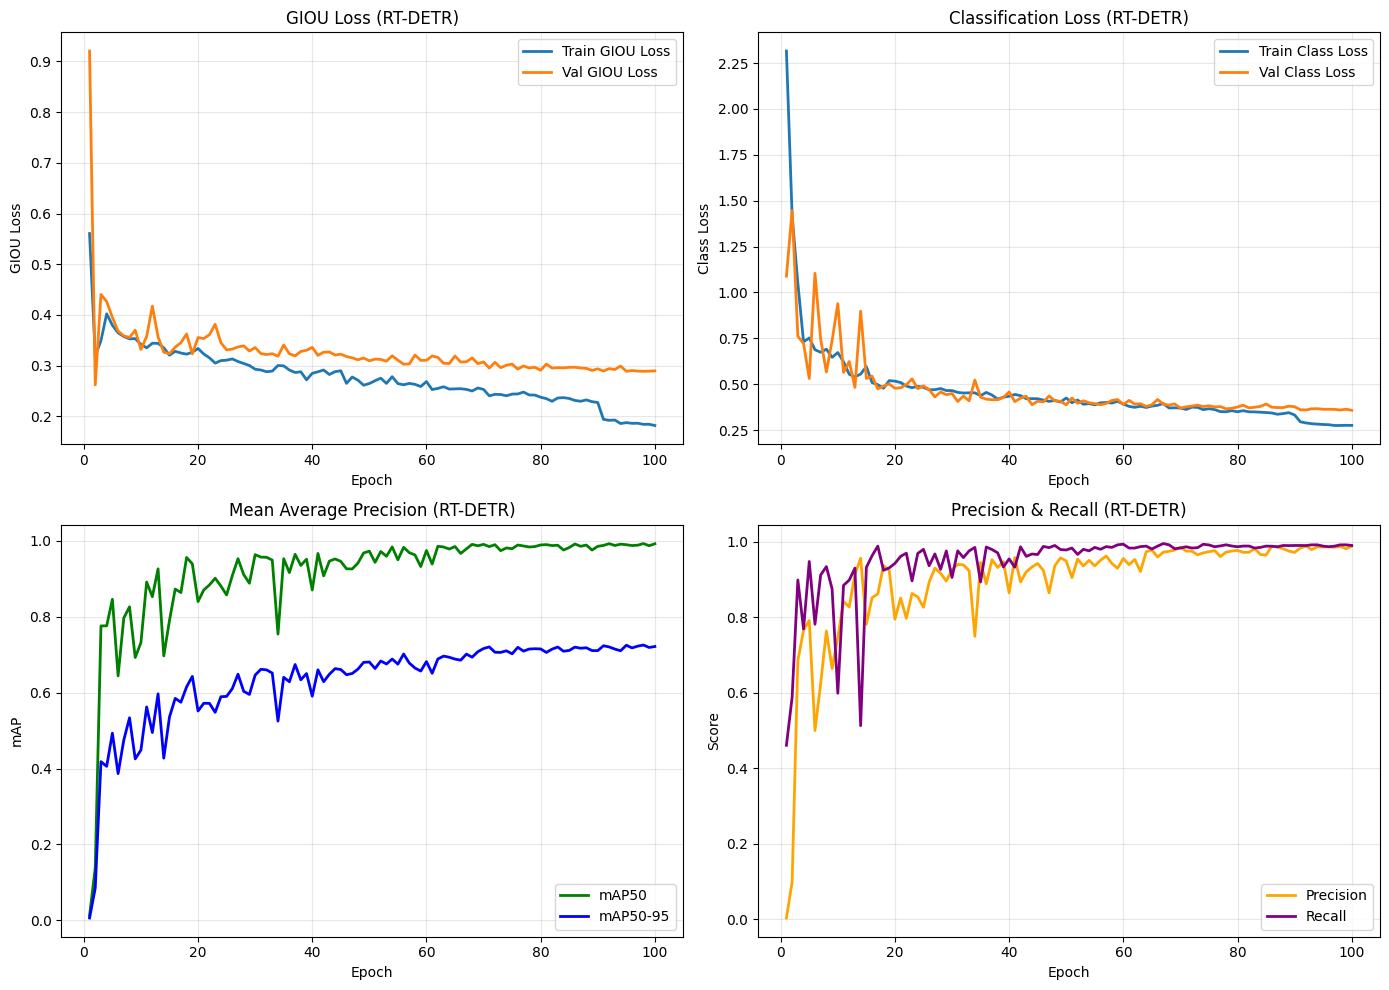

✅ Training curves saved to: /content/drive/MyDrive/thesis/results/rtdetr_training_curves.png


In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# Load training results CSV
# results_csv = os.path.join(CKPT_DIR, 'rtdetr_boreal', 'results.csv')
results_csv = Path('/content/drive/MyDrive/thesis/checkpoints/rtdetr_boreal/results.csv')
if os.path.exists(results_csv):
    df = pd.read_csv(results_csv)
    df.columns = df.columns.str.strip()  # Remove whitespace

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Loss curves
    axes[0, 0].plot(df['epoch'], df['train/giou_loss'], label='Train GIOU Loss', linewidth=2)
    axes[0, 0].plot(df['epoch'], df['val/giou_loss'], label='Val GIOU Loss', linewidth=2)
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('GIOU Loss')
    axes[0, 0].set_title('GIOU Loss (RT-DETR)')
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.3)

    axes[0, 1].plot(df['epoch'], df['train/cls_loss'], label='Train Class Loss', linewidth=2)
    axes[0, 1].plot(df['epoch'], df['val/cls_loss'], label='Val Class Loss', linewidth=2)
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Class Loss')
    axes[0, 1].set_title('Classification Loss (RT-DETR)')
    axes[0, 1].legend()
    axes[0, 1].grid(alpha=0.3)

    # Metrics
    axes[1, 0].plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP50', linewidth=2, color='green')
    axes[1, 0].plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP50-95', linewidth=2, color='blue')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('mAP')
    axes[1, 0].set_title('Mean Average Precision (RT-DETR)')
    axes[1, 0].legend()
    axes[1, 0].grid(alpha=0.3)

    axes[1, 1].plot(df['epoch'], df['metrics/precision(B)'], label='Precision', linewidth=2, color='orange')
    axes[1, 1].plot(df['epoch'], df['metrics/recall(B)'], label='Recall', linewidth=2, color='purple')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Score')
    axes[1, 1].set_title('Precision & Recall (RT-DETR)')
    axes[1, 1].legend()
    axes[1, 1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'rtdetr_training_curves.png'), dpi=150, bbox_inches='tight')
    plt.show()

    print('✅ Training curves saved to:', os.path.join(RESULTS_DIR, 'rtdetr_training_curves.png'))
else:
    print(f'⚠️  Results CSV not found at {results_csv}')

## Test prediction on sample images


0: 640x640 1 smoke, 16.2ms
1: 640x640 1 smoke, 16.2ms
2: 640x640 1 smoke, 16.2ms
3: 640x640 1 smoke, 16.2ms
4: 640x640 1 smoke, 16.2ms
5: 640x640 1 smoke, 16.2ms
Speed: 4.4ms preprocess, 16.2ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 640)


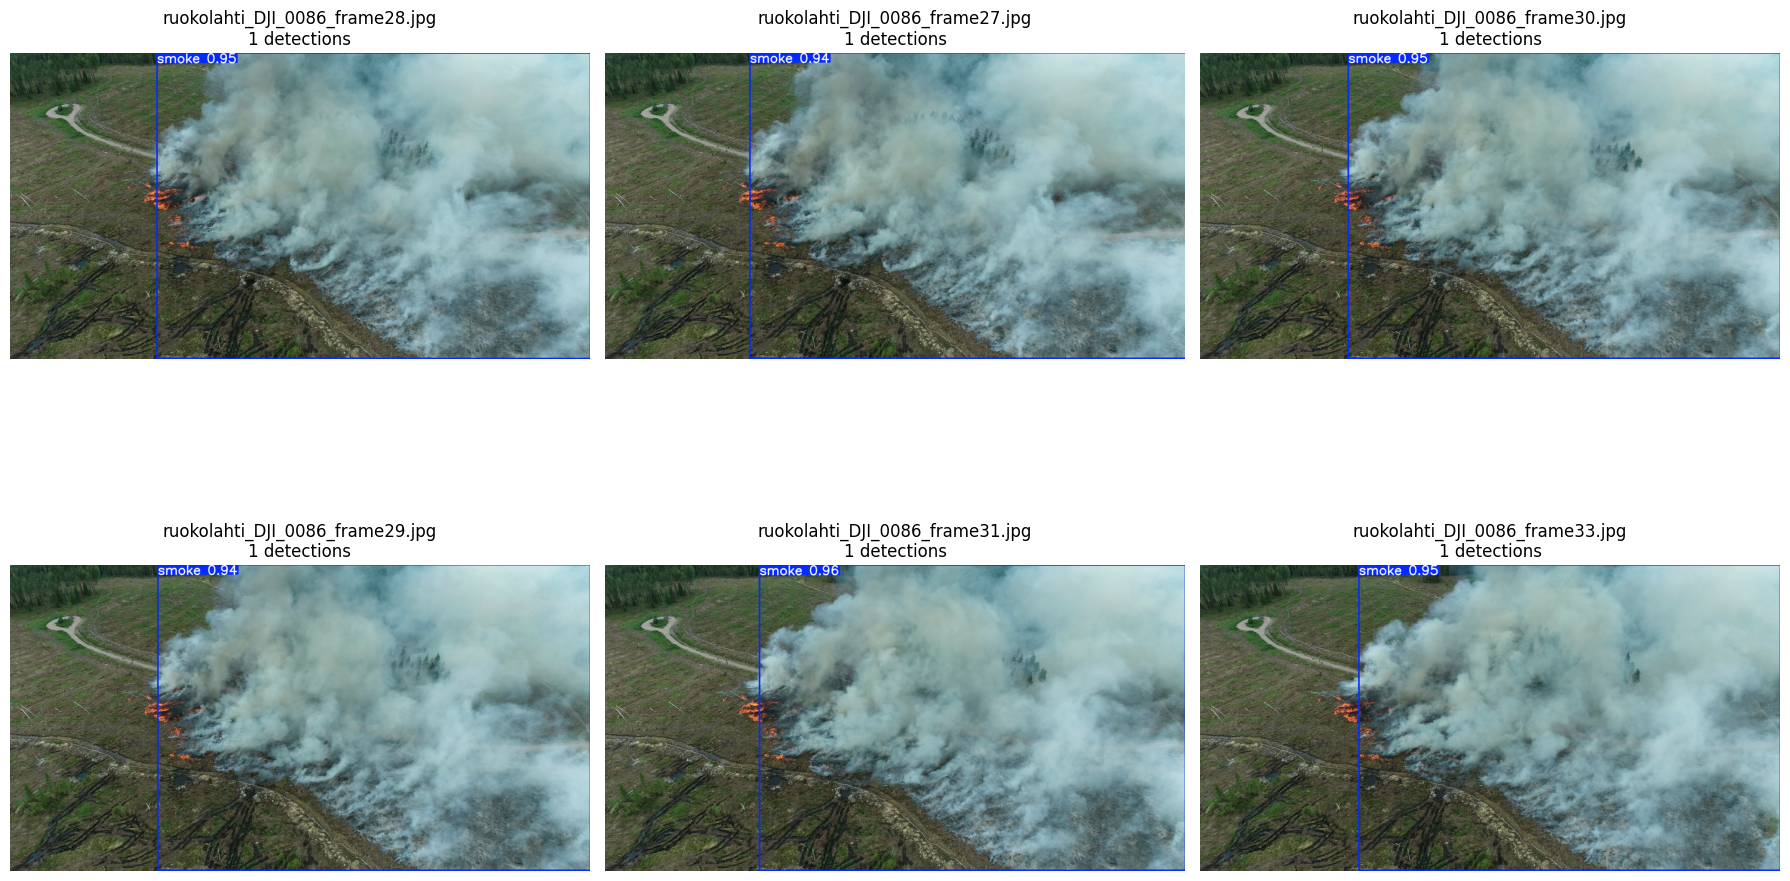

 Predictions visualized!


In [13]:
# Get random test images
test_img_dir = DATA_ROOT / 'images' / 'test'
test_images = list(test_img_dir.glob('*'))[:6]  # Get 6 random images

RESULTS_DIR = Path('/content/drive/MyDrive/thesis/results')

# Run inference
results_pred = model_rtdetr_best.predict(
    source=test_images,
    imgsz=IMG_SIZE,
    conf=0.25,  # Confidence threshold
    device=DEVICE,
    save=False
)

# Visualize predictions
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, (result, img_path) in enumerate(zip(results_pred, test_images)):
    # Get annotated image
    img_array = result.plot()  # Returns image with boxes drawn
    img_rgb = cv2.cvtColor(img_array, cv2.COLOR_BGR2RGB)

    axes[idx].imshow(img_rgb)
    axes[idx].set_title(f"{img_path.name}\n{len(result.boxes)} detections")
    axes[idx].axis('off')

plt.tight_layout()

plt.savefig(RESULTS_DIR / 'rtdetrl_boreal_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

print(" Predictions visualized!")

## 6 — Final Test Evaluation (Ruokolahti — reported in thesis)

In [14]:
# Run once only — the number reported in the thesis
metrics_rtdetr = model_rtdetr_best.val(
    data   = BOREAL_YAML,
    split  = 'test',
    imgsz  = 640,
    batch  = 32,
    device = 0 if torch.cuda.is_available() else 'cpu'
)

print('\n=== RT-DETR — Test Results (Ruokolahti) ===')
print(f'  Precision : {metrics_rtdetr.box.mp:.4f}')
print(f'  Recall    : {metrics_rtdetr.box.mr:.4f}')
print(f'  mAP50     : {metrics_rtdetr.box.map50:.4f}')
print(f'  mAP50-95  : {metrics_rtdetr.box.map:.4f}')

Ultralytics 8.4.24 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
rt-detr-l summary: 310 layers, 31,985,795 parameters, 0 gradients, 103.4 GFLOPs
val: Fast image access ✅ (ping: 0.4±0.1 ms, read: 6.7±2.8 MB/s, size: 2368.9 KB)
val: Scanning /content/drive/MyDrive/thesis/data/boreal/labels/test.cache... 1765 images, 3 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1765/1765 493.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 56/56 2.2s/it 2:05
                   all       1765       1884      0.982       0.92      0.923      0.656
Speed: 0.8ms preprocess, 4.6ms inference, 0.0ms loss, 0.5ms postprocess per image
Results saved to /content/runs/detect/val2

=== RT-DETR — Test Results (Ruokolahti) ===
  Precision : 0.9823
  Recall    : 0.9204
  mAP50     : 0.9233
  mAP50-95  : 0.6559


## 7 — Efficiency Profiling (FPS, GPU Memory, Parameters)

In [15]:
import time

def profile_model(model_path, model_name, imgsz=640, n_runs=200):
    model  = YOLO(model_path)
    pt     = model.model.eval()
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    pt.to(device)
    dummy  = torch.randn(1, 3, imgsz, imgsz).to(device)

    with torch.no_grad():
        for _ in range(10): pt(dummy)  # warmup

    torch.cuda.reset_peak_memory_stats() if device == 'cuda' else None
    t0 = time.time()
    with torch.no_grad():
        for _ in range(n_runs): pt(dummy)
    fps    = n_runs / (time.time() - t0)
    mem    = torch.cuda.max_memory_allocated() / 1e6 if device == 'cuda' else 0
    params = sum(p.numel() for p in pt.parameters()) / 1e6

    print(f'{model_name}: FPS={fps:.1f}  GPU={mem:.0f} MB  Params={params:.1f} M')
    return {'model': model_name, 'fps': round(fps,1),
            'gpu_mem_mb': round(mem,1), 'params_m': round(params,2)}

eff_rtdetr = profile_model(BEST_RTDETR, 'RT-DETR-l')

RT-DETR-l: FPS=22.8  GPU=1140 MB  Params=32.8 M


## 8 — Append Results to Drive CSVs

In [16]:
import pandas as pd

det_csv = os.path.join(RESULTS_DIR, 'detection_results.csv')
eff_csv = os.path.join(RESULTS_DIR, 'efficiency_results.csv')

# New rows for RT-DETR
new_det = pd.DataFrame([
    {'model':'RT-DETR-l', 'split':'test',
     'precision':metrics_rtdetr.box.mp, 'recall':metrics_rtdetr.box.mr,
     'mAP50':metrics_rtdetr.box.map50,  'mAP50_95':metrics_rtdetr.box.map},
    {'model':'RT-DETR-l', 'split':'val',
     'precision':val_rtdetr.box.mp, 'recall':val_rtdetr.box.mr,
     'mAP50':val_rtdetr.box.map50,  'mAP50_95':val_rtdetr.box.map},
])
new_eff = pd.DataFrame([eff_rtdetr])

# Append to existing CSVs from notebook 02
if os.path.exists(det_csv):
    det = pd.concat([pd.read_csv(det_csv), new_det], ignore_index=True)
else:
    det = new_det

if os.path.exists(eff_csv):
    eff = pd.concat([pd.read_csv(eff_csv), new_eff], ignore_index=True)
else:
    eff = new_eff

det.to_csv(det_csv, index=False)
eff.to_csv(eff_csv, index=False)

print('=== All Detection Results So Far ===')
print(det.round(4).to_string(index=False))
print('\n=== All Efficiency Results So Far ===')
print(eff.to_string(index=False))
print('\nSaved to:', RESULTS_DIR)

=== All Detection Results So Far ===
    model split  precision  recall  mAP50  mAP50_95
  YOLOv8s  test     0.8332  0.9098 0.8941    0.7488
  YOLOv5s  test     0.8974  0.9124 0.9239    0.7297
  YOLOv8s   val     0.9800  0.9953 0.9935    0.7857
  YOLOv5s   val     0.9942  0.9915 0.9935    0.7924
RT-DETR-l  test     0.9823  0.9204 0.9233    0.6559
RT-DETR-l   val     0.9861  0.9898 0.9929    0.7255

=== All Efficiency Results So Far ===
    model   fps  gpu_mem_mb  params_m
  YOLOv8s 107.3       536.6     11.14
  YOLOv5s  97.6       522.5      9.12
RT-DETR-l  22.8      1139.8     32.81

Saved to: /content/drive/MyDrive/thesis/results


## ✅ Summary

| Model | Type | Checkpoint |
|-------|------|------------|
| YOLOv8s | CNN | `checkpoints/yolov8s_boreal/weights/best.pt` |
| YOLOv5s | CNN | `checkpoints/yolov5s_boreal/weights/best.pt` |
| RT-DETR-l | Transformer | `checkpoints/rtdetr_boreal/weights/best.pt` |

**Note for thesis:** TFNet (Liu et al., 2025) is discussed in the literature review as the
representative transformer approach. RT-DETR is used as the implemented transformer baseline
because no official TFNet code is available.

**Next:** `04_vision_mamba.ipynb` — our main model